In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from sotodlib import core
from sotodlib.tod_ops.flags import get_det_bias_flags

from latcom.utils.cut_utils import get_cut_sources, get_det_cal_cuts
import latcom.utils.yield_utils as yd
from latcom.utils.optical_loading import (
    aso_tubes,
    lf_tubes,
    ot_from_ufm,
    pwv_interp,
    so_nominal_tubes,
)

%load_ext autoreload
%autoreload 2

# ASO Yields

In [2]:
ctx = core.Context("../../ctxs/smurf_det_preproc.yaml")
ufm = "mv49"
band = "090"
ot = ot_from_ufm(ufm)

start = dt.datetime(2026, 6, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 6, 30, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)


pwv = pwv_interp()

obs_ctx_list = []
for i, obs in enumerate(obs_list):
    cur_ot = str(obs["obs_id"]).split("_")[2][3:]
    obs_id = str(obs["obs_id"])
    if cur_ot in lf_tubes:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_lf_260604.yaml"))
    else:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_260604.yaml"))

toby_df = yd.aso_toby_df
pton_df = yd.ptown_df

In [ ]:
for obs_id, ctx_path in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        ctx = core.Context(ctx_path)
        break
aso_metas = []
for obs_id, ctx_path in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = ctx.get_meta(
                obs_id,
                dets={
                    "dets:stream_id": "ufm_" + str(ufm),
                    "dets:wafer.bandpass": "f" + str(band),
                },
            )
            aso_metas.append(meta)

        except:
            continue

obs_1780451618_lati4_111
obs_1780451618_lati4_111


/global/u2/j/jorlo/dev/sotodlib/sotodlib/core/metadata/loader.py:996: MetadataSpecWarning: metadata spec contains 'unpack' and 'name' entries; ignoring the latter (except to set the 'label', maybe).
  warnings.warn(


obs_1780456042_lati4_111
obs_1780458280_lati4_111
obs_1780461905_lati4_111
obs_1780466512_lati4_111
obs_1780469106_lati4_111
obs_1780472708_lati4_111
obs_1780476312_lati4_111
obs_1780485790_lati4_111
obs_1780487541_lati4_111
obs_1780491164_lati4_111
obs_1780500457_lati4_111
obs_1780506303_lati4_111
obs_1780508760_lati4_111
obs_1780512397_lati4_111


In [ ]:
obs_ids = []
times = []
naive_yields = []
noise_yields = []
c_cuts = []
cut_names = []
pwvs = []

for i in range(len(aso_metas)):
    meta = metas[i]
    obs_id = meta.obs_info.obs_id
    if "mv" in ufm:
        if band == "090":
            ufm_band = 1
        elif band == "150":
            ufm_band = 2
    if "uv" in ufm:
        if band == "220":
            ufm_band = 1
        elif band == "280":
            ufm_band = 2
    wafer_flag = np.array([ufm in _ufm for _ufm in meta.det_info.stream_id])

    if len(wafer_flag) == 0:
        print(f"No det_info for obs {obs_id}")


    naive_yield = meta.shape[0] / 860

    print(
        "Number of dets after get_bias_flags: ",
        naive_yield * 860,
        " current yield ",
        naive_yield,
    )
    bp = (meta.det_cal.bg % 4) // 2

    if ufm_band == 1:
        net_flag = wafer_flag * (bp == 0)
    elif ufm_band == 2:
        net_flag = wafer_flag * (bp == 1)

    raw_cal = np.nanmedian(meta.abscal.raw_abscal_rj[net_flag])
    if "noise" in meta.preprocess:
        wnoise = meta.preprocess.noise.white_noise[net_flag]
    elif "noiseT" in meta.preprocess:
        wnoise = meta.preprocess.noiseT.white_noise[net_flag]
    else:
        print(f"Error: no valid noise key in {meta.preprocess.keys()}")
    ndet = len(np.where(wnoise != 0)[0])
    noise_yield = ndet / 860
    noise_yields.append(noise_yield)

    n_cut, cut_name = get_cut_sources(meta)
    n_cuts.append(n_cut)
    cut_names.append(cut_name)
    obs_ids.append(obs_id.split("_")[1])
    times.append(dt.datetime.fromtimestamp(int(obs_id.split("_")[1])))
    naive_yields.append(naive_yield)

    print(
        "Number of dets with noise estimate: ",
        noise_yield * 860,
        " current yield ",
        noise_yield,
    )
    pwvs.append(pwv(obs_id.split("_")[1]))

In [ ]:
import matplotlib.dates as mdates

fig, ax = plt.subplots()
noise = ax.plot(times, noise_yields, label="Noise yields")
bias = ax.plot(times, naive_yields, label="Naive yields")

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Yield")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

ax.axhline(
    pton_df.loc[pton_df.labels == f"{band}_{ufm}", "yields"].to_numpy(), label="PTon"
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = noise + bias + pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"yield_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"yield_{ufm}_{band}.png", dpi=600)

plt.show()

In [ ]:
cuts = cut_names[0]
for i in range(len(cut_names)):
    if i == 0:
        cut_dict = {}
        for name in cuts:
            cut_dict[name] = []
    for j, name in enumerate(cuts):
        cut_dict[name].append(n_cuts[i][j])

In [ ]:
fig, ax = plt.subplots()
lns = []
for cut, n_cut in cut_dict.items():
    cur_ln = ax.plot(times, np.array(n_cut) / 860, label=cut)
    if np.amax(n_cut)>10 and cut !="source_flags":
        lns += cur_ln

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Fractional Dets Cut")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = lns+ pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"cuts_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"cuts_{ufm}_{band}.png", dpi=600)

plt.show()

# SO Nominal Yields

In [ ]:
start = dt.datetime(2025, 10, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2025, 10, 30, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)

obs_ids_list = []
for i, obs in enumerate(obs_list):
    obs_ids_list.append(str(obs["obs_id"]))

In [46]:
old_ctx = core.Context("../../ctxs/old_smurf_det_preproc.yaml")
nominal_metas = []
for obs_id in obs_ids_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = old_ctx.get_meta(
                obs_id,
                dets={
                    "dets:stream_id": "ufm_" + str(ufm),
                    "dets:wafer.bandpass": "f" + str(band),
                },
            )
            nominal_metas.append(meta)

        except:
            continue

obs_1759277309_lati4_111
obs_1759279469_lati4_111
obs_1759283082_lati4_111
obs_1759286672_lati4_111
obs_1759291142_lati4_111
obs_1759293429_lati4_111
obs_1759297035_lati4_111
obs_1759300634_lati4_111
obs_1759304241_lati4_111
obs_1759307681_lati4_111
obs_1759309856_lati4_111
obs_1759313445_lati4_111
obs_1759319136_lati4_111
obs_1759321587_lati4_111
obs_1759325207_lati4_111
obs_1759332347_lati4_111
obs_1759337257_lati4_111
obs_1759339814_lati4_111
obs_1759352281_lati4_111
obs_1759354032_lati4_111
obs_1759357620_lati4_111
obs_1759367543_lati4_111
obs_1759369163_lati4_111
obs_1759372751_lati4_111
obs_1759377299_lati4_111
obs_1759379466_lati4_111
obs_1759383059_lati4_111
obs_1759386659_lati4_111
obs_1759390265_lati4_111
obs_1759393847_lati4_111
obs_1759395572_lati4_111
obs_1759399155_lati4_111
obs_1759404891_lati4_111
obs_1759407263_lati4_111
obs_1759410834_lati4_111
obs_1759438885_lati4_111
obs_1759441252_lati4_111
obs_1759444834_lati4_111
obs_1759448377_lati4_111
obs_1759450536_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1759641864_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1759645464_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1759645464_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1759649066_lati4_111


...

obs_1761441310_lati4_111
obs_1761446450_lati4_111
obs_1761448231_lati4_111
obs_1761455608_lati4_111
obs_1761457237_lati4_111
obs_1761460858_lati4_111
obs_1761464445_lati4_111
obs_1761468053_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1761468053_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1761472660_lati4_111
obs_1761475255_lati4_111
obs_1761478870_lati4_111
obs_1761480822_lati4_111
obs_1761484265_lati4_111
obs_1761488890_lati4_111
obs_1761491478_lati4_111
obs_1761494139_lati4_111
obs_1761496441_lati4_111
obs_1761500192_lati4_111
obs_1761503057_lati4_111
obs_1761508489_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1761508489_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1761512213_lati4_111
obs_1761515821_lati4_111
obs_1761519425_lati4_111
obs_1761525014_lati4_111
obs_1761526755_lati4_111
obs_1761530366_lati4_111
obs_1761533975_lati4_111
obs_1761541079_lati4_111
obs_1761542247_lati4_111
obs_1761545856_lati4_111
obs_1761549459_lati4_111
obs_1761553063_lati4_111
obs_1761557675_lati4_111
obs_1761560256_lati4_111
obs_1761561827_lati4_111
obs_1761564529_lati4_111
obs_1761568153_lati4_111
obs_1761572767_lati4_111
obs_1761575347_lati4_111
obs_1761600745_lati4_111
obs_1761604475_lati4_111
obs_1761608076_lati4_111
obs_1761611680_lati4_111
obs_1761616285_lati4_111
obs_1761618859_lati4_111
obs_1761622469_lati4_111
obs_1761626078_lati4_111
obs_1761629677_lati4_111
obs_1761634285_lati4_111
obs_1761636860_lati4_111
obs_1761640473_lati4_111
obs_1761644087_lati4_111
obs_1761650155_lati4_111
obs_1761653892_lati4_111
obs_1761657484_lati4_111
obs_1761661096_lati4_111
obs_1761670477_lati4_111
obs_1761687518_lati4_111
obs_1761688897_lati4_111
obs_1761692513_lati4_111


In [67]:
obs_ids = []
times = []
naive_yields = []
noise_yields = []
n_cuts = []
cut_names = []
pwvs = []

for i in range(len(nominal_metas)):
    meta = metas[i]
    obs_id = meta.obs_info.obs_id
    if "mv" in ufm:
        if band == "090":
            ufm_band = 1
        elif band == "150":
            ufm_band = 2
    if "uv" in ufm:
        if band == "220":
            ufm_band = 1
        elif band == "280":
            ufm_band = 2

    n_cut, cut_name = get_cut_sources(meta)


    wafer_flag = np.array([ufm in _ufm for _ufm in meta.det_info.stream_id])

    if len(wafer_flag) == 0:
        print(f"No det_info for obs {obs_id}")

    print(obs_id)
    naive_yield = meta.shape[0] / 860

    print(
        "Number of dets with no cuts: ",
        naive_yield * 860,
        " current yield ",
        naive_yield,
    )
    bp = (meta.det_cal.bg % 4) // 2
    try:
        if ufm_band == 1:
            net_flag = wafer_flag * (bp == 0)
        elif ufm_band == 2:
            net_flag = wafer_flag * (bp == 1)
    except: continue

    raw_cal = np.nanmedian(meta.abscal.raw_abscal_rj[net_flag])
    if "noise" in meta.preprocess:
        wnoise = meta.preprocess.noise.white_noise[net_flag]
    elif "noiseT" in meta.preprocess:
        wnoise = meta.preprocess.noiseT.white_noise[net_flag]
    else:
        print(f"Error: no valid noise key in {meta.preprocess.keys()}")
    ndet = len(np.where(wnoise != 0)[0])
    noise_yield = ndet / 860
    noise_yields.append(noise_yield)
    naive_yields.append(naive_yield)
    times.append(dt.datetime.fromtimestamp(int(obs_id.split("_")[1])))
    obs_ids.append(obs_id.split("_")[1])
    n_cuts.append(n_cut)
    cut_names.append(cut_name)
    print(
        "Number of dets with noise estimate: ",
        noise_yield * 860,
        " current yield ",
        noise_yield,
    )
    pwvs.append(pwv(obs_id.split("_")[1]))


obs_1759277309_lati4_111
Number of dets with no cuts:  380.0  current yield  0.4418604651162791
Number of dets with noise estimate:  378.0  current yield  0.43953488372093025
obs_1759279469_lati4_111
Number of dets with no cuts:  392.0  current yield  0.4558139534883721
Number of dets with noise estimate:  375.0  current yield  0.436046511627907
obs_1759283082_lati4_111
Number of dets with no cuts:  390.0  current yield  0.45348837209302323
Number of dets with noise estimate:  375.0  current yield  0.436046511627907
obs_1759286672_lati4_111
Number of dets with no cuts:  392.0  current yield  0.4558139534883721
Number of dets with noise estimate:  381.0  current yield  0.44302325581395346
obs_1759291142_lati4_111
Number of dets with no cuts:  380.0  current yield  0.4418604651162791
Number of dets with noise estimate:  377.0  current yield  0.4383720930232558
obs_1759293429_lati4_111
Number of dets with no cuts:  377.0  current yield  0.4383720930232558
Number of dets with noise estimat

In [69]:
len(times)

475

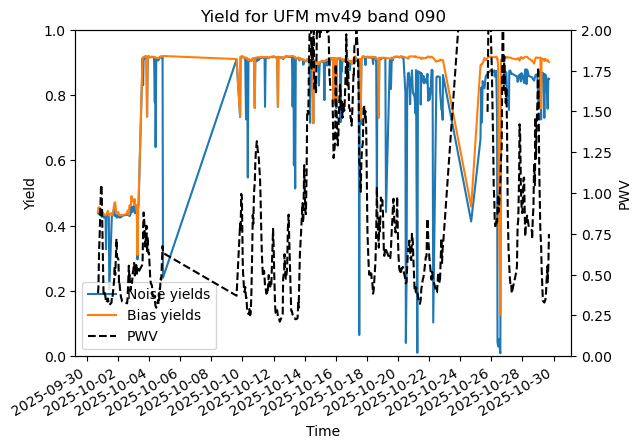

In [70]:
import matplotlib.dates as mdates

fig, ax = plt.subplots()
noise = ax.plot(times, noise_yields, label="Noise yields")
bias = ax.plot(times, naive_yields, label="Naive yields")

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Yield")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

ax.axhline(
    pton_df.loc[pton_df.labels == f"{band}_{ufm}", "yields"].to_numpy(), label="PTon"
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = noise + bias + pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"old_yield_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"old_yield_{ufm}_{band}.png", dpi=600)

plt.show()

In [71]:
cuts = cut_names[0]
for i in range(len(cut_names)):
    if i == 0:
        cut_dict = {}
        for name in cuts:
            cut_dict[name] = []
    for j, name in enumerate(cuts):
        cut_dict[name].append(n_cuts[i][j])


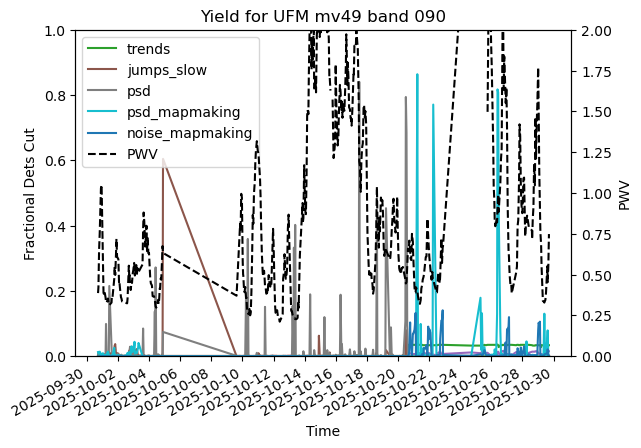

In [73]:
fig, ax = plt.subplots()
lns = []
for cut, n_cut in cut_dict.items():
    cur_ln = ax.plot(times, np.array(n_cut) / 860, label=cut)
    if np.amax(n_cut)>30 and cut !="source_flags":
        lns += cur_ln

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Fractional Dets Cut")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = lns+ pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"old_cuts_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"old_cuts_{ufm}_{band}.png", dpi=600)

plt.show()